# Network Intrusion Detection - Complete ML Pipeline
This notebook builds a complete, production-ready machine learning pipeline for network intrusion detection.

**Pipeline Stages:**
1. Data Preprocessing & Feature Engineering
2. Exploratory Data Analysis (EDA)
3. Feature Selection
4. Model Building & Hyperparameter Tuning (XGBoost)
5. Model Evaluation & Metrics
6. Model Interpretability

## Section 1: IMPORTS & SETUP

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
from pymongo import MongoClient
print("✓ All libraries imported successfully")


✓ All libraries imported successfully


## Section 1.5: MONGODB SETUP & UTILITIES


In [44]:
# MongoDB Connection Setup
class MongoDBHandler:
    """Utility class for MongoDB operations"""
    
    def __init__(self, uri="mongodb://localhost:27017/", db_name="network_intrusion"):
        """
        Initialize MongoDB connection
        Args:
            uri: MongoDB connection URI
            db_name: Database name to use
        """
        self.client = MongoClient(uri)
        self.db = self.client[db_name]
        print(f"✓ Connected to MongoDB database: {db_name}")
    
    def insert_data(self, collection_name, dataframe, drop_existing=False):
        """Insert DataFrame data into MongoDB collection"""
        collection = self.db[collection_name]
        
        if drop_existing:
            collection.delete_many({})
            print(f"  Dropped existing {collection_name} collection")
        
        # Convert DataFrame to list of dictionaries
        data = dataframe.to_dict(orient="records")
        result = collection.insert_many(data)
        print(f"✓ Inserted {len(result.inserted_ids)} records into {collection_name}")
        return result
    
    def query_data(self, collection_name, query={}, limit=None):
        """Query data from MongoDB collection"""
        collection = self.db[collection_name]
        cursor = collection.find(query)
        
        if limit:
            cursor = cursor.limit(limit)
        
        data = list(cursor)
        return pd.DataFrame(data)
    
    def get_collection_stats(self, collection_name):
        """Get statistics about a collection"""
        collection = self.db[collection_name]
        count = collection.count_documents({})
        print(f"Collection '{collection_name}' contains {count} documents")
        return count
    
    def collection_exists(self, collection_name):
        """Check if a collection exists in the database"""
        return collection_name in self.db.list_collection_names()
    
    def drop_collection(self, collection_name):
        """Drop a collection from the database"""
        self.db[collection_name].drop()
        print(f"✓ Dropped collection: {collection_name}")
    
    def close(self):
        """Close MongoDB connection"""
        self.client.close()
        print("✓ MongoDB connection closed")

# Initialize MongoDB handler
mongo = MongoDBHandler(db_name="network_intrusion_db")
print("✓ MongoDB handler initialized")

✓ Connected to MongoDB database: network_intrusion_db
✓ MongoDB handler initialized


## Section 2: DATA LOADING & INITIAL EXPLORATION

In [45]:
# Load datasets from MongoDB (with fallback to CSV)
print("Loading datasets from MongoDB...")

# Check if data exists in MongoDB collections
if mongo.collection_exists('training_raw') and mongo.collection_exists('testing_raw'):
    print("✓ Found existing data in MongoDB collections")
    df = mongo.query_data('training_raw')
    df_test = mongo.query_data('testing_raw')
    print("✓ Loaded training and testing sets from MongoDB")
else:
    print("⚠️  Data not found in MongoDB. Loading from CSV and storing to MongoDB...")
    # Load from CSV files
    df = pd.read_csv('CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv')
    df_test = pd.read_csv('CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv')
    
    # Store to MongoDB for future use
    mongo.insert_data('training_raw', df, drop_existing=True)
    mongo.insert_data('testing_raw', df_test, drop_existing=True)
    print("✓ CSV data loaded and stored to MongoDB")

print(f"\n📊 Dataset Summary:")
print(f"Training set shape: {df.shape}")
print(f"Testing set shape: {df_test.shape}")
print(f"\nColumn names ({len(df.columns)} features):")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Loading datasets from MongoDB...
✓ Found existing data in MongoDB collections
✓ Loaded training and testing sets from MongoDB

📊 Dataset Summary:
Training set shape: (175341, 46)
Testing set shape: (82332, 46)

Column names (46 features):
['_id', 'id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First few rows:


,_id,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,69f386f5ee7eb3c295c6b944,1,0.121478,tcp,-,FIN,6,4,258,172,...,1,1,0,0,0,1,1,0,Normal,0
1,69f386f5ee7eb3c295c6b945,2,0.649902,tcp,-,FIN,14,38,734,42014,...,1,2,0,0,0,1,6,0,Normal,0
2,69f386f5ee7eb3c295c6b946,3,1.623129,tcp,-,FIN,8,16,364,13186,...,1,3,0,0,0,2,6,0,Normal,0
3,69f386f5ee7eb3c295c6b947,4,1.681642,tcp,ftp,FIN,12,12,628,770,...,1,3,1,1,0,2,1,0,Normal,0
4,69f386f5ee7eb3c295c6b948,5,0.449454,tcp,-,FIN,10,6,534,268,...,1,40,0,0,0,2,39,0,Normal,0


In [46]:
# Check data types and missing values
print("📋 Data Inspection from MongoDB Collection")
print("="*60)
print("Data Info:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nClass distribution (Label):")
print(df['label'].value_counts())
print(f"\nAttack categories:")
print(df['attack_cat'].value_counts())
print("\n✓ All data successfully retrieved from MongoDB collections")

📋 Data Inspection from MongoDB Collection
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 46 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _id                175341 non-null  object 
 1   id                 175341 non-null  int64  
 2   dur                175341 non-null  float64
 3   proto              175341 non-null  object 
 4   service            175341 non-null  object 
 5   state              175341 non-null  object 
 6   spkts              175341 non-null  int64  
 7   dpkts              175341 non-null  int64  
 8   sbytes             175341 non-null  int64  
 9   dbytes             175341 non-null  int64  
 10  rate               175341 non-null  float64
 11  sttl               175341 non-null  int64  
 12  dttl               175341 non-null  int64  
 13  sload              175341 non-null  float64
 14  dload              175341 non-null  float64
 15

## MongoDB Data Storage & Retrieval


In [47]:
# MongoDB Collections Status
print("="*60)
print("MONGODB DATA WAREHOUSE STATUS")
print("="*60)
print("\n✓ Raw Data Collections:")
mongo.get_collection_stats('training_raw')
mongo.get_collection_stats('testing_raw')
print("\n📌 Additional collections will be created during processing:")
print("   • training_processed: After preprocessing & feature engineering")
print("   • testing_processed: After preprocessing & feature engineering")
print("   • training_scaled: After standardization/normalization")
print("   • testing_scaled: After standardization/normalization")
print("   • model_predictions: Model predictions and probabilities")
print("   • model_metrics: Model evaluation metrics and hyperparameters")

MONGODB DATA WAREHOUSE STATUS

✓ Raw Data Collections:
Collection 'training_raw' contains 175341 documents
Collection 'testing_raw' contains 82332 documents

📌 Additional collections will be created during processing:
   • training_processed: After preprocessing & feature engineering
   • testing_processed: After preprocessing & feature engineering
   • training_scaled: After standardization/normalization
   • testing_scaled: After standardization/normalization
   • model_predictions: Model predictions and probabilities
   • model_metrics: Model evaluation metrics and hyperparameters


## Section 3: DATA PREPROCESSING

In [48]:
# Step 1: Retrieve raw data from MongoDB and prepare for processing
print("Step 1: Retrieving raw data from MongoDB for preprocessing...")
df_processing = mongo.query_data('training_raw')

# Create a copy and drop unnecessary columns
df_processed = df_processing.copy()
columns_to_drop = ['id', 'attack_cat']  # 'id' is identifier, 'attack_cat' is granular version
df_processed = df_processed.drop(columns=columns_to_drop)

# Separate target variable
X = df_processed.drop('label', axis=1)
y = df_processed['label']

print(f"✓ Raw data retrieved from MongoDB")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Remaining features: {X.shape[1]}")

# Store intermediate results
mongo.insert_data('training_basic_processed', df_processed, drop_existing=True)

Step 1: Retrieving raw data from MongoDB for preprocessing...
✓ Raw data retrieved from MongoDB
Features shape: (175341, 43)
Target shape: (175341,)
Remaining features: 43
  Dropped existing training_basic_processed collection
✓ Inserted 175341 records into training_basic_processed


InsertManyResult([ObjectId('69f386f5ee7eb3c295c6b944'), ObjectId('69f386f5ee7eb3c295c6b945'), ObjectId('69f386f5ee7eb3c295c6b946'), ObjectId('69f386f5ee7eb3c295c6b947'), ObjectId('69f386f5ee7eb3c295c6b948'), ObjectId('69f386f5ee7eb3c295c6b949'), ObjectId('69f386f5ee7eb3c295c6b94a'), ObjectId('69f386f5ee7eb3c295c6b94b'), ObjectId('69f386f5ee7eb3c295c6b94c'), ObjectId('69f386f5ee7eb3c295c6b94d'), ObjectId('69f386f5ee7eb3c295c6b94e'), ObjectId('69f386f5ee7eb3c295c6b94f'), ObjectId('69f386f5ee7eb3c295c6b950'), ObjectId('69f386f5ee7eb3c295c6b951'), ObjectId('69f386f5ee7eb3c295c6b952'), ObjectId('69f386f5ee7eb3c295c6b953'), ObjectId('69f386f5ee7eb3c295c6b954'), ObjectId('69f386f5ee7eb3c295c6b955'), ObjectId('69f386f5ee7eb3c295c6b956'), ObjectId('69f386f5ee7eb3c295c6b957'), ObjectId('69f386f5ee7eb3c295c6b958'), ObjectId('69f386f5ee7eb3c295c6b959'), ObjectId('69f386f5ee7eb3c295c6b95a'), ObjectId('69f386f5ee7eb3c295c6b95b'), ObjectId('69f386f5ee7eb3c295c6b95c'), ObjectId('69f386f5ee7eb3c295c6b9

In [49]:
# Step 2: Identify categorical and numerical features
print("Step 2: Feature type identification...")
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"✓ Feature analysis complete")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")

# Store feature metadata in MongoDB for future reference
feature_metadata = {
    'categorical': categorical_features,
    'numerical': numerical_features,
    'total_features': len(X.columns),
    'timestamp': pd.Timestamp.now()
}
mongo.db['feature_metadata'].insert_one(feature_metadata)
print("✓ Feature metadata stored in MongoDB")

Step 2: Feature type identification...
✓ Feature analysis complete
Categorical features (4): ['_id', 'proto', 'service', 'state']

Numerical features (39): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
✓ Feature metadata stored in MongoDB


In [50]:
# Step 3: Handle missing values and encode categorical features
print("\nStep 3: Categorical encoding and missing value handling...")

# ── DROP _id FIRST (MongoDB ObjectId, not a feature) ──────────────────────────
if '_id' in X.columns:
    X = X.drop(columns=['_id'])
    print(" Dropped '_id' column (MongoDB identifier, not a feature)")

# Only encode true categorical text features
categorical_features = ['proto', 'service', 'state']
for col in categorical_features:
    X[col] = X[col].fillna('unknown')

# Encode categorical features using LabelEncoder
label_encoders = {}
encoding_mapping = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    # FIX: use str keys so MongoDB accepts the document
    encoding_mapping[col] = {str(i): c for i, c in enumerate(le.classes_)}
    print(f"  Encoded '{col}': {len(le.classes_)} unique values → {list(le.classes_)[:5]}{'...' if len(le.classes_) > 5 else ''}")

# Handle missing values for numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
print(f"  Filled missing numeric values with median ({len(numeric_features)} numeric features)")

print(f"\n Categorical features encoded and missing values handled")
print(f"Final feature set ({len(X.columns)} cols): {X.columns.tolist()}")

# Store encoding mappings in MongoDB for future predictions
encoding_doc = {
    'encodings': encoding_mapping,
    'categorical_features': categorical_features,
    'timestamp': pd.Timestamp.now().isoformat()
}
mongo.db['label_encodings'].drop()   # replace old mappings
mongo.db['label_encodings'].insert_one(encoding_doc)
print("Encoding mappings stored in MongoDB")



Step 3: Categorical encoding and missing value handling...
 Dropped '_id' column (MongoDB identifier, not a feature)
  Encoded 'proto': 133 unique values → ['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus']...
  Encoded 'service': 13 unique values → ['-', 'dhcp', 'dns', 'ftp', 'ftp-data']...
  Encoded 'state': 9 unique values → ['CON', 'ECO', 'FIN', 'INT', 'PAR']...
  Filled missing numeric values with median (42 numeric features)

 Categorical features encoded and missing values handled
Final feature set (42 cols): ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_port

In [51]:
# Step 4: Feature Engineering - Create derived features
print("Step 4: Feature engineering - creating derived features...")

X['byte_ratio'] = np.where(X['dbytes'] != 0, X['sbytes'] / (X['dbytes'] + 1e-6), 0)
X['packet_ratio'] = np.where(X['dpkts'] != 0, X['spkts'] / (X['dpkts'] + 1e-6), 0)
X['packet_rate'] = np.where(X['dur'] != 0, (X['spkts'] + X['dpkts']) / (X['dur'] + 1e-6), 0)
X['total_traffic'] = X['sbytes'] + X['dbytes']
X['avg_pkt_size_src'] = np.where(X['spkts'] != 0, X['sbytes'] / (X['spkts'] + 1e-6), 0)
X['avg_pkt_size_dst'] = np.where(X['dpkts'] != 0, X['dbytes'] / (X['dpkts'] + 1e-6), 0)
X['load_ratio'] = np.where(X['dload'] != 0, X['sload'] / (X['dload'] + 1e-6), 0)
X['loss_ratio'] = np.where((X['sloss'] + X['dloss']) != 0, X['sloss'] / (X['sloss'] + X['dloss'] + 1e-6), 0)

# Replace infinite values
X = X.replace([np.inf, -np.inf], 0)

print(f"✓ Feature engineering complete: {X.shape[1]} features")
print(f"✓ New features created: byte_ratio, packet_ratio, packet_rate, total_traffic,")
print(f"  avg_pkt_size_src, avg_pkt_size_dst, load_ratio, loss_ratio")

# Store engineered features to MongoDB
df_with_target = X.copy()
df_with_target['label'] = y
mongo.insert_data('training_engineered', df_with_target, drop_existing=True)
print("✓ Engineered features stored in MongoDB collection: training_engineered")

Step 4: Feature engineering - creating derived features...
✓ Feature engineering complete: 50 features
✓ New features created: byte_ratio, packet_ratio, packet_rate, total_traffic,
  avg_pkt_size_src, avg_pkt_size_dst, load_ratio, loss_ratio
  Dropped existing training_engineered collection
✓ Inserted 175341 records into training_engineered
✓ Engineered features stored in MongoDB collection: training_engineered


In [52]:
# Step 5: Split data into train/validation with stratification
print("Step 5: Train/validation split with stratification...")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data split complete")
print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Class imbalance ratio: {y_train.value_counts()[1] / y_train.value_counts()[0]:.4f}")

# Store train/validation split to MongoDB
df_train_split = X_train.copy()
df_train_split['label'] = y_train
df_train_split['split_type'] = 'train'

df_val_split = X_val.copy()
df_val_split['label'] = y_val
df_val_split['split_type'] = 'validation'

mongo.insert_data('training_split', pd.concat([df_train_split, df_val_split], ignore_index=True), drop_existing=True)
print("✓ Train/validation split stored in MongoDB")

Step 5: Train/validation split with stratification...
✓ Data split complete
Training set size: (140272, 50)
Validation set size: (35069, 50)

Class distribution in training set:
label
1    95472
0    44800
Name: count, dtype: int64
Class imbalance ratio: 2.1311
  Dropped existing training_split collection
✓ Inserted 175341 records into training_split
✓ Train/validation split stored in MongoDB


In [53]:
# Step 6: Apply SMOTE to handle class imbalance
print("Step 6: Applying SMOTE for class imbalance handling...")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"✓ SMOTE applied successfully")
print(f"Training set size after SMOTE: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"✓ Perfect class balance achieved (1:1 ratio)")

# Store balanced training data to MongoDB
df_train_balanced = pd.DataFrame(X_train_smote, columns=X_train.columns)
df_train_balanced['label'] = y_train_smote
mongo.insert_data('training_balanced', df_train_balanced, drop_existing=True)
print("✓ Balanced training data stored in MongoDB")

Step 6: Applying SMOTE for class imbalance handling...
✓ SMOTE applied successfully
Training set size after SMOTE: (190944, 50)
Class distribution after SMOTE:
label
1    95472
0    95472
Name: count, dtype: int64
✓ Perfect class balance achieved (1:1 ratio)
  Dropped existing training_balanced collection
✓ Inserted 190944 records into training_balanced
✓ Balanced training data stored in MongoDB


In [54]:
# Step 7: Standardize/Normalize features
print("Step 7: Feature scaling and normalization...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)

print(f"✓ Features scaled successfully")
print(f"Mean of scaled features (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Std of scaled features (should be ~1): {X_train_scaled.std().mean():.6f}")

# Store scaled data to MongoDB
df_train_scaled_storage = X_train_scaled.copy()
df_train_scaled_storage['label'] = y_train_smote
mongo.insert_data('training_scaled', df_train_scaled_storage, drop_existing=True)

df_val_scaled_storage = X_val_scaled.copy()
df_val_scaled_storage['label'] = y_val
mongo.insert_data('testing_scaled', df_val_scaled_storage, drop_existing=True)

print("✓ Scaled training data stored in MongoDB: training_scaled")
print("✓ Scaled validation data stored in MongoDB: testing_scaled")

Step 7: Feature scaling and normalization...
✓ Features scaled successfully
Mean of scaled features (should be ~0): -0.000000
Std of scaled features (should be ~1): 1.000003
  Dropped existing training_scaled collection
✓ Inserted 190944 records into training_scaled
  Dropped existing testing_scaled collection
✓ Inserted 35069 records into testing_scaled
✓ Scaled training data stored in MongoDB: training_scaled
✓ Scaled validation data stored in MongoDB: testing_scaled


## Section 4: EXPLORATORY DATA ANALYSIS (EDA)

In [55]:
# MongoDB Data Pipeline Summary
print("\n" + "="*70)
print("MONGODB DATA PIPELINE SUMMARY")
print("="*70)
print("\n📊 Collections created during preprocessing:")
collections_to_show = [
    'training_raw',
    'training_basic_processed',
    'training_engineered',
    'training_split',
    'training_balanced',
    'training_scaled',
    'testing_scaled'
]

for collection in collections_to_show:
    if mongo.collection_exists(collection):
        mongo.get_collection_stats(collection)

print("\n📋 Metadata collections:")
print(f"  • feature_metadata: Feature types and counts")
print(f"  • label_encodings: Categorical feature encodings")
print("\n✓ All preprocessing data successfully stored in MongoDB!")
print("="*70)


MONGODB DATA PIPELINE SUMMARY

📊 Collections created during preprocessing:
Collection 'training_raw' contains 175341 documents
Collection 'training_basic_processed' contains 175341 documents
Collection 'training_engineered' contains 175341 documents
Collection 'training_split' contains 175341 documents
Collection 'training_balanced' contains 190944 documents
Collection 'training_scaled' contains 190944 documents
Collection 'testing_scaled' contains 35069 documents

📋 Metadata collections:
  • feature_metadata: Feature types and counts
  • label_encodings: Categorical feature encodings

✓ All preprocessing data successfully stored in MongoDB!


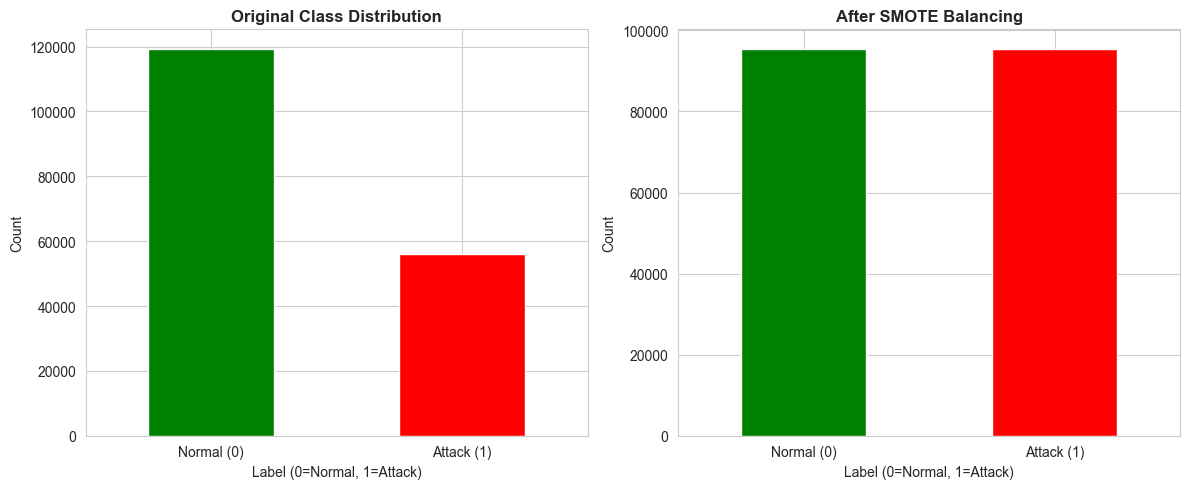

Class distribution visualization complete


In [56]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y.value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Original Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Label (0=Normal, 1=Attack)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)

pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('After SMOTE Balancing', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Label (0=Normal, 1=Attack)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)

plt.tight_layout()
plt.show()
print("Class distribution visualization complete")

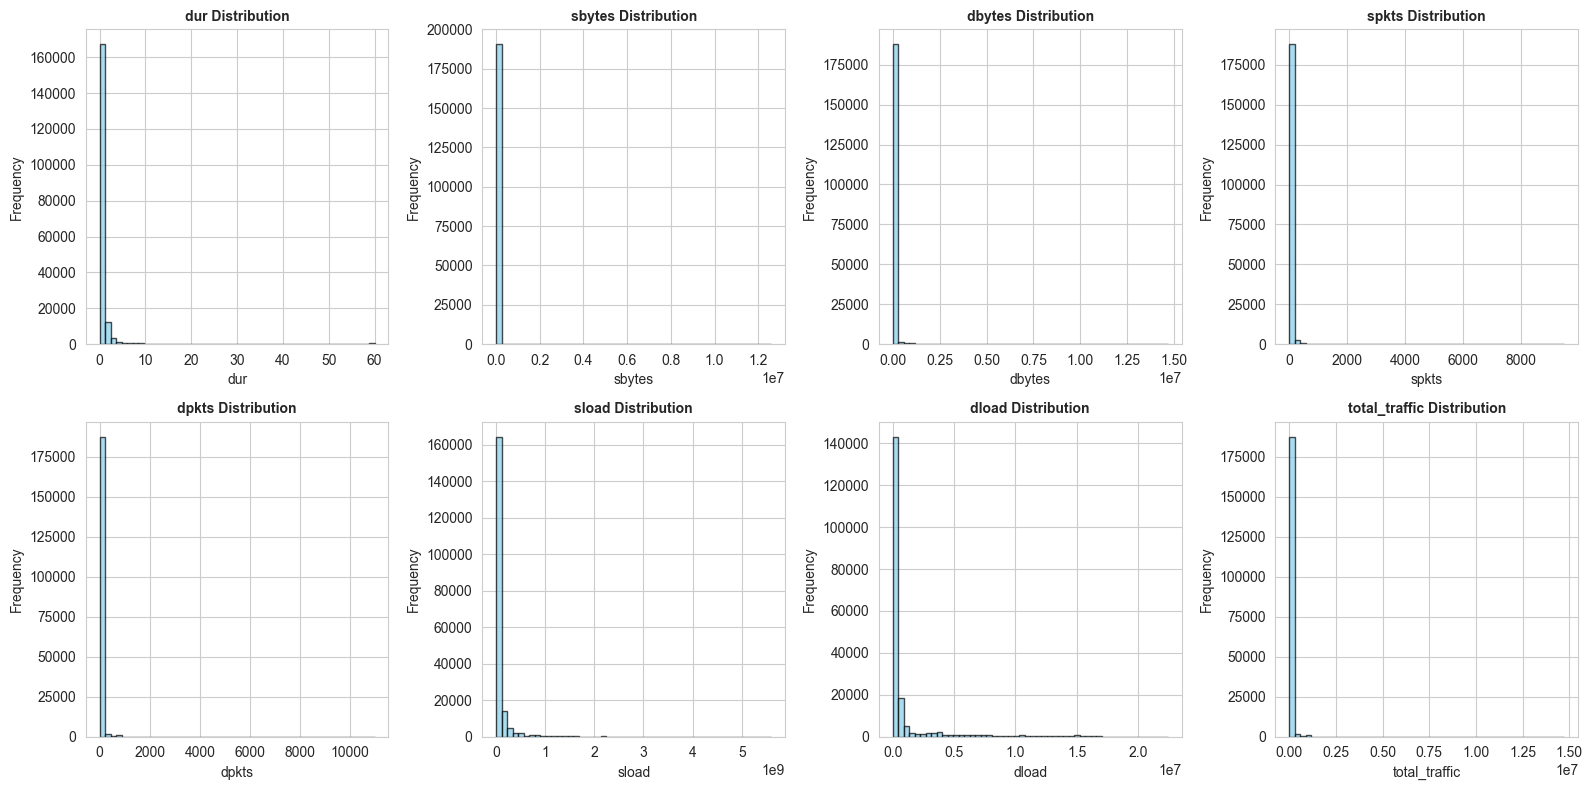

Feature distribution plots complete


In [57]:
# Distribution of key numerical features
key_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'total_traffic']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    axes[idx].hist(X_train_smote[feature], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Feature distribution plots complete")

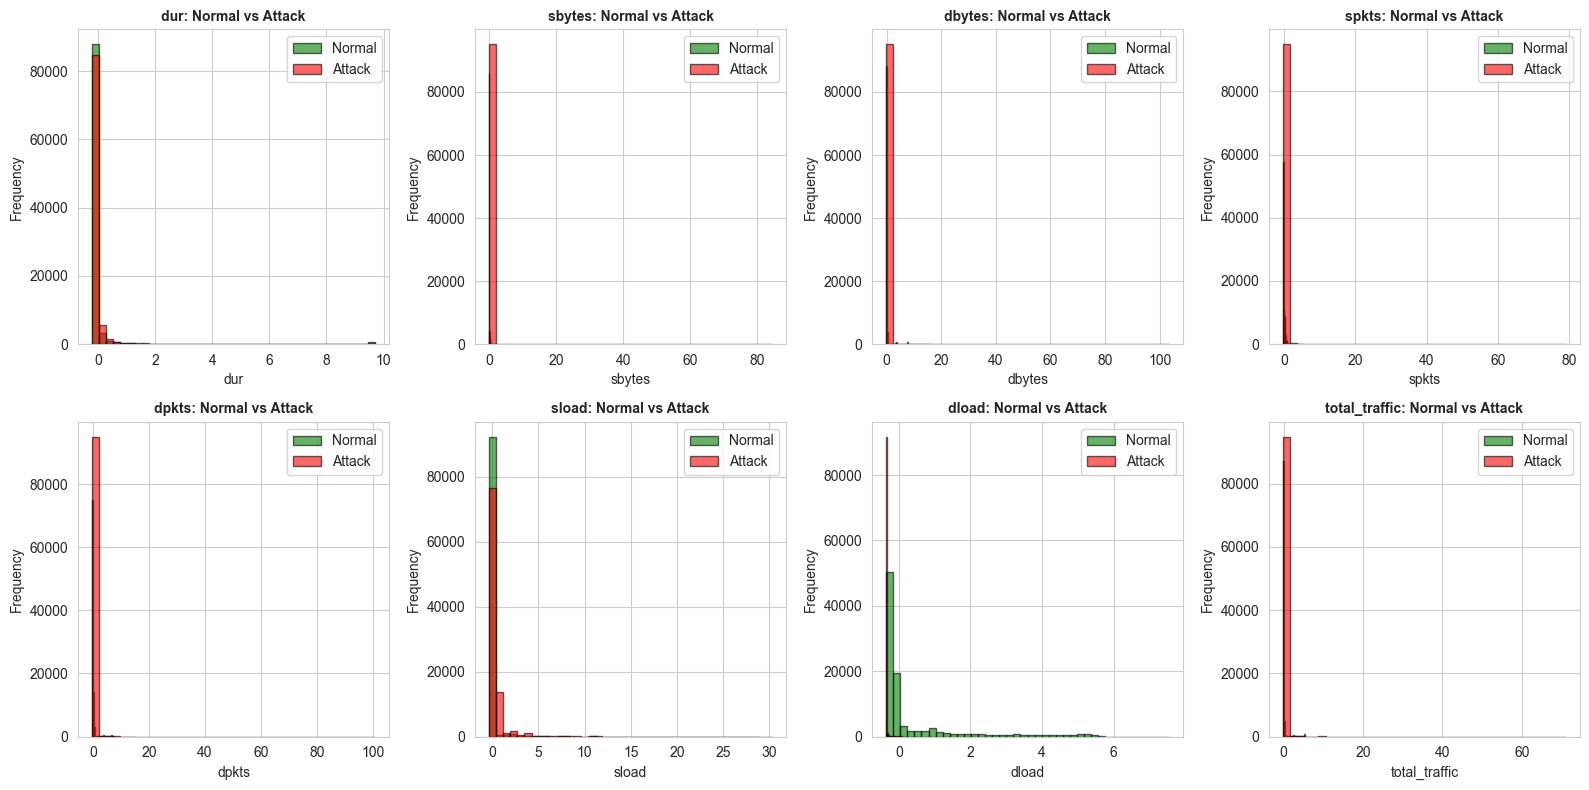

Normal vs Attack comparison complete


In [58]:
# Normal vs Attack comparison for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    normal_data = X_train_scaled[y_train_smote == 0][feature]
    attack_data = X_train_scaled[y_train_smote == 1][feature]
    
    axes[idx].hist(normal_data, bins=40, alpha=0.6, label='Normal', color='green', edgecolor='black')
    axes[idx].hist(attack_data, bins=40, alpha=0.6, label='Attack', color='red', edgecolor='black')
    axes[idx].set_title(f'{feature}: Normal vs Attack', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()
print("Normal vs Attack comparison complete")

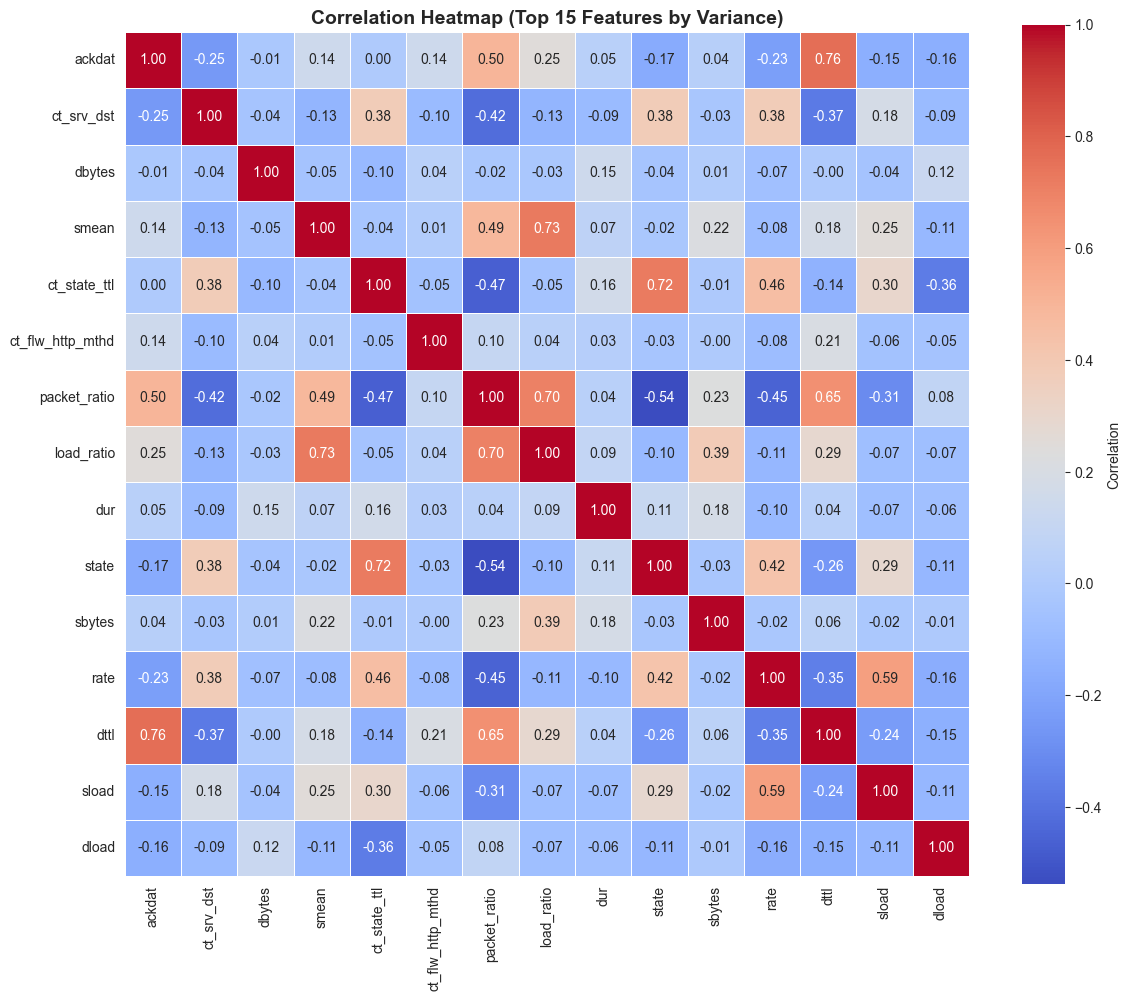

Correlation heatmap complete


In [59]:
# Correlation heatmap for top features
top_features_for_corr = X_train_scaled.var().nlargest(15).index.tolist()
correlation_matrix = X_train_scaled[top_features_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Top 15 Features by Variance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation heatmap complete")

## Section 5: FEATURE SELECTION

In [60]:
# Remove highly correlated features (threshold: 0.95)
print("Feature Selection: Removing highly correlated features...")

def remove_high_correlation_features(df, threshold=0.95):
    """Remove highly correlated features"""
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return to_drop

high_corr_features = remove_high_correlation_features(X_train_scaled, threshold=0.95)
print(f"Features with high correlation (>0.95): {high_corr_features}")

X_train_filtered = X_train_scaled.drop(columns=high_corr_features)
X_val_filtered = X_val_scaled.drop(columns=high_corr_features)

print(f"\n✓ Feature reduction: {X_train_scaled.shape[1]} → {X_train_filtered.shape[1]} features")
print(f"✓ Removed: {len(high_corr_features)} redundant features")

# Store filtered data to MongoDB
df_train_filtered = X_train_filtered.copy()
df_train_filtered['label'] = y_train_smote
mongo.insert_data('training_filtered', df_train_filtered, drop_existing=True)

df_val_filtered_storage = X_val_filtered.copy()
df_val_filtered_storage['label'] = y_val
mongo.insert_data('testing_filtered', df_val_filtered_storage, drop_existing=True)

print("✓ Filtered features stored in MongoDB")

Feature Selection: Removing highly correlated features...
Features with high correlation (>0.95): ['dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_srv_dst', 'packet_rate', 'avg_pkt_size_src', 'avg_pkt_size_dst', 'load_ratio']

✓ Feature reduction: 50 → 38 features
✓ Removed: 12 redundant features
  Dropped existing training_filtered collection
✓ Inserted 190944 records into training_filtered
  Dropped existing testing_filtered collection
✓ Inserted 35069 records into testing_filtered
✓ Filtered features stored in MongoDB


In [61]:
# Train quick XGBoost model for feature importance
print("Training XGBoost for feature importance analysis...")
xgb_importance = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                               random_state=42, n_jobs=-1, verbose=0, use_label_encoder=False)
xgb_importance.fit(X_train_filtered, y_train_smote, verbose=0)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'importance': xgb_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 20 most important features:")
print(feature_importance.head(20).to_string(index=False))

Training XGBoost for feature importance analysis...

Top 20 most important features:
          feature  importance
             sttl    0.529458
       loss_ratio    0.103122
             dttl    0.037794
       ct_srv_src    0.036585
            spkts    0.032115
    total_traffic    0.028562
 ct_dst_sport_ltm    0.025385
            smean    0.021395
      trans_depth    0.020828
            dmean    0.019817
     ct_state_ttl    0.014901
          service    0.013031
       byte_ratio    0.011742
            state    0.011693
            proto    0.010795
            dpkts    0.009495
     packet_ratio    0.009306
           sbytes    0.008351
response_body_len    0.006829
           tcprtt    0.006649


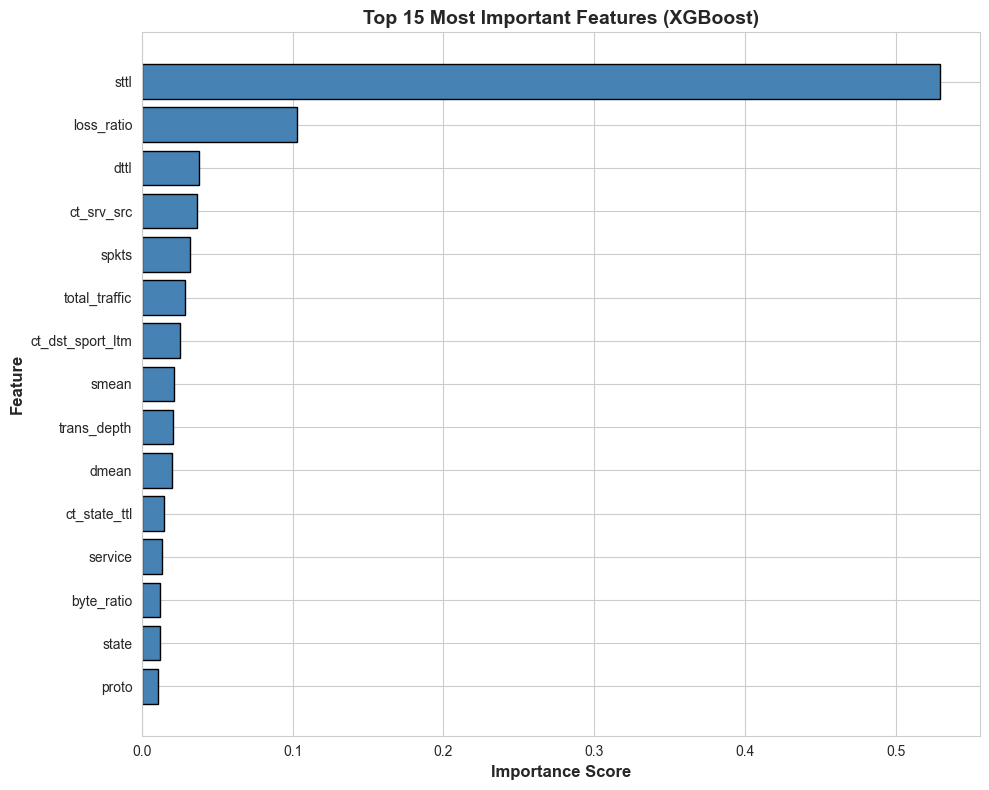

Feature importance visualization complete


In [62]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_15_features_imp = feature_importance.head(15)
plt.barh(top_15_features_imp['feature'], top_15_features_imp['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance visualization complete")

In [63]:
# Select features with 95% cumulative importance
print("Feature Importance Selection...")

cumsum_importance = feature_importance['importance'].cumsum() / feature_importance['importance'].sum()
n_features_95 = (cumsum_importance <= 0.95).sum() + 1
selected_features = feature_importance.head(n_features_95)['feature'].tolist()

print(f"Number of features for 95% importance: {n_features_95}")
print(f"Cumulative importance: {cumsum_importance.iloc[n_features_95-1]:.4f}")
print(f"\nSelected features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

X_train_final = X_train_filtered[selected_features]
X_val_final = X_val_filtered[selected_features]

print(f"\n✓ Final feature set: {X_train_final.shape[1]} features")

# Store final selected features to MongoDB
df_train_final = X_train_final.copy()
df_train_final['label'] = y_train_smote
mongo.insert_data('training_final', df_train_final, drop_existing=True)

df_val_final = X_val_final.copy()
df_val_final['label'] = y_val
mongo.insert_data('testing_final', df_val_final, drop_existing=True)

# Store feature importance to MongoDB
feature_importance_doc = {
    'selected_features': selected_features,
    'num_selected': len(selected_features),
    'importance_scores': feature_importance.head(n_features_95).to_dict('records'),
    'cumulative_importance_threshold': 0.95,
    'timestamp': pd.Timestamp.now()
}
mongo.db['feature_importance'].insert_one(feature_importance_doc)

print("✓ Final feature set and importance scores stored in MongoDB")

Feature Importance Selection...
Number of features for 95% importance: 19
Cumulative importance: 0.9512

Selected features (19):
  1. sttl
  2. loss_ratio
  3. dttl
  4. ct_srv_src
  5. spkts
  6. total_traffic
  7. ct_dst_sport_ltm
  8. smean
  9. trans_depth
  10. dmean
  11. ct_state_ttl
  12. service
  13. byte_ratio
  14. state
  15. proto
  16. dpkts
  17. packet_ratio
  18. sbytes
  19. response_body_len

✓ Final feature set: 19 features
  Dropped existing training_final collection
✓ Inserted 190944 records into training_final
  Dropped existing testing_final collection
✓ Inserted 35069 records into testing_final
✓ Final feature set and importance scores stored in MongoDB


## Section 6: MODEL BUILDING & HYPERPARAMETER TUNING

In [64]:
# Define hyperparameter combinations to test
test_params = [
    {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8},
    {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8},
]

print(f"Testing {len(test_params)} hyperparameter combinations with 5-fold CV...")
print("="*70)

Testing 3 hyperparameter combinations with 5-fold CV...


In [65]:
# Hyperparameter tuning with cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_score = 0
best_params = {}
results = []

for params in test_params:
    xgb = XGBClassifier(**params, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
    cv_scores = cross_val_score(xgb, X_train_final, y_train_smote, cv=cv, scoring='f1')
    mean_score = cv_scores.mean()
    results.append({
        'params': params,
        'mean_f1': mean_score,
        'std_f1': cv_scores.std()
    })
    print(f"Params: {params}")
    print(f"  Mean F1: {mean_score:.4f} (±{cv_scores.std():.4f})\n")
    
    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("="*70)
print(f"✓ Best F1 Score: {best_score:.4f}")
print(f"Best Parameters: {best_params}")

Params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8}
  Mean F1: 0.9496 (±0.0009)

Params: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9}
  Mean F1: 0.9461 (±0.0009)

Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}
  Mean F1: 0.9479 (±0.0011)

✓ Best F1 Score: 0.9496
Best Parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8}


In [66]:
# Train final model with best parameters
print("Training final XGBoost model with best parameters...")
model = XGBClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train_final, y_train_smote)
print("✓ Model training complete")

Training final XGBoost model with best parameters...
✓ Model training complete


## Section 7: MODEL EVALUATION

In [67]:
# Make predictions and calculate metrics
y_pred_train = model.predict(X_train_final)
y_pred_val = model.predict(X_val_final)
y_pred_proba_val = model.predict_proba(X_val_final)[:, 1]

# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train_smote, y_pred_train)
val_accuracy = accuracy_score(y_val, y_pred_val)
val_precision = precision_score(y_val, y_pred_val)
val_recall = recall_score(y_val, y_pred_val)
val_f1 = f1_score(y_val, y_pred_val)
val_roc_auc = roc_auc_score(y_val, y_pred_proba_val)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Training Accuracy:  {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:   {val_recall:.4f}")
print(f"Validation F1-Score: {val_f1:.4f}")
print(f"Validation ROC-AUC:  {val_roc_auc:.4f}")
print("="*60)

MODEL PERFORMANCE METRICS
Training Accuracy:  0.9521
Validation Accuracy: 0.9418
Validation Precision: 0.9684
Validation Recall:   0.9453
Validation F1-Score: 0.9567
Validation ROC-AUC:  0.9907


In [68]:
# Confusion Matrix Analysis
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

print("\nCONFUSION MATRIX ANALYSIS")
print("="*60)
print(f"True Negatives (TN):   {tn:6d} - Correctly classified as Normal")
print(f"False Positives (FP):  {fp:6d} - Normal flagged as Attack")
print(f"False Negatives (FN):  {fn:6d} - Attack missed (CRITICAL) ⚠️")
print(f"True Positives (TP):   {tp:6d} - Correctly classified as Attack")
print("="*60)
print(f"\n⚠️  FALSE NEGATIVES: {fn} (missed attacks)")
print(f"   False Negative Rate: {fn / (fn + tp):.4f} ({100*fn/(fn+tp):.2f}%)")
print(f"\n✓ FALSE POSITIVES: {fp} (false alarms)")
print(f"   False Positive Rate: {fp / (fp + tn):.4f} ({100*fp/(fp+tn):.2f}%)")


CONFUSION MATRIX ANALYSIS
True Negatives (TN):    10464 - Correctly classified as Normal
False Positives (FP):     736 - Normal flagged as Attack
False Negatives (FN):    1306 - Attack missed (CRITICAL) ⚠️
True Positives (TP):    22563 - Correctly classified as Attack

⚠️  FALSE NEGATIVES: 1306 (missed attacks)
   False Negative Rate: 0.0547 (5.47%)

✓ FALSE POSITIVES: 736 (false alarms)
   False Positive Rate: 0.0657 (6.57%)


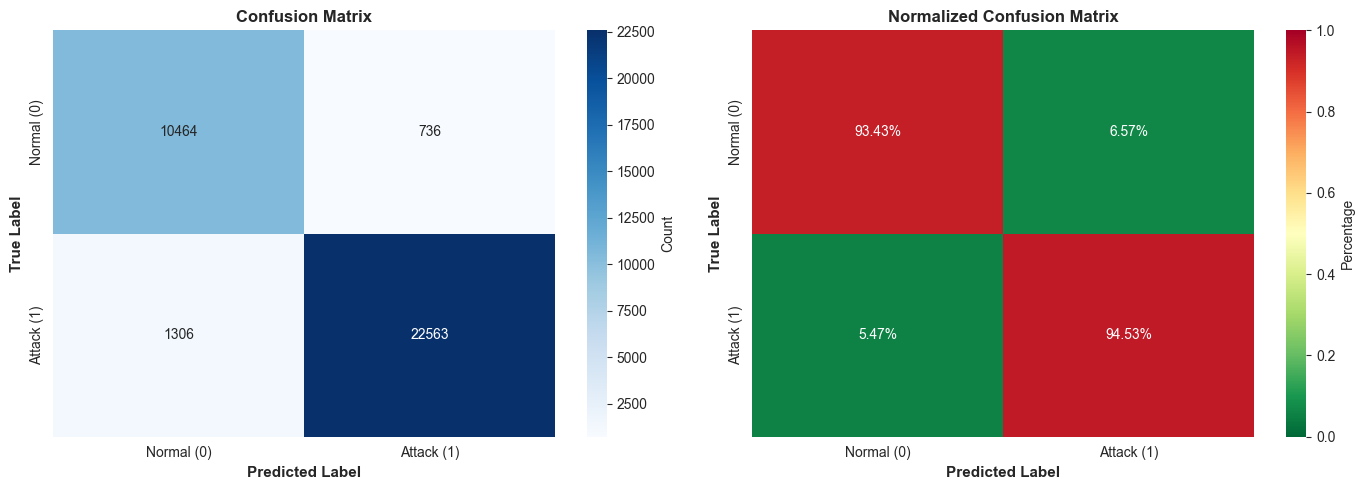

In [69]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'],
            cbar_kws={'label': 'Count'})
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=axes[1],
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'],
            cbar_kws={'label': 'Percentage'},
            vmin=0, vmax=1)
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

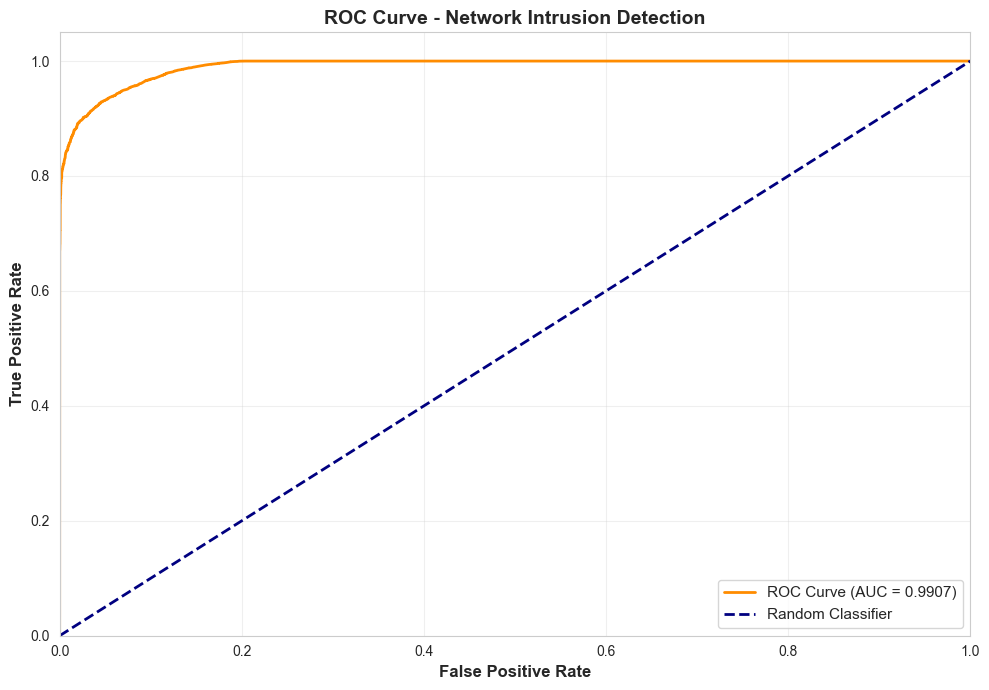

In [70]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_val)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Network Intrusion Detection', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

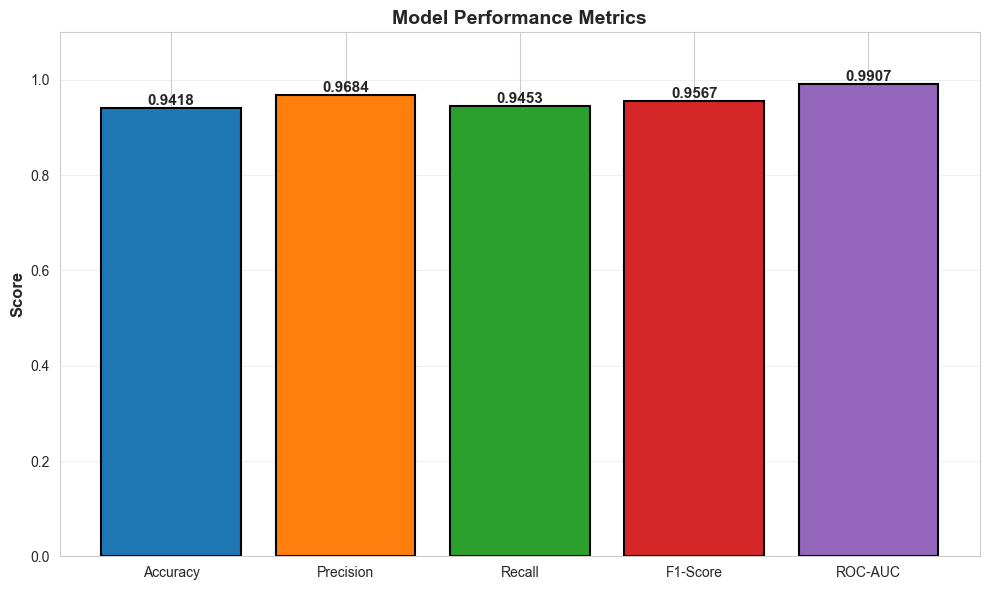

In [71]:
# Performance Metrics Visualization
metrics = {
    'Accuracy': val_accuracy,
    'Precision': val_precision,
    'Recall': val_recall,
    'F1-Score': val_f1,
    'ROC-AUC': val_roc_auc
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='black', linewidth=1.5)

for bar, value in zip(bars, metrics.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8: MODEL INTERPRETABILITY

In [72]:
# Feature Importance from final model
final_feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFINAL MODEL FEATURE IMPORTANCE")
print("="*60)
print(final_feature_importance.to_string(index=False))
print("="*60)


FINAL MODEL FEATURE IMPORTANCE
          feature  importance
             sttl    0.634485
       loss_ratio    0.074795
             dttl    0.036657
       ct_srv_src    0.032781
 ct_dst_sport_ltm    0.024178
     ct_state_ttl    0.023245
            dmean    0.018295
      trans_depth    0.017693
            smean    0.016691
    total_traffic    0.016673
            state    0.016048
            spkts    0.014393
          service    0.014037
            proto    0.012727
            dpkts    0.012588
       byte_ratio    0.011113
           sbytes    0.009606
     packet_ratio    0.007454
response_body_len    0.006542


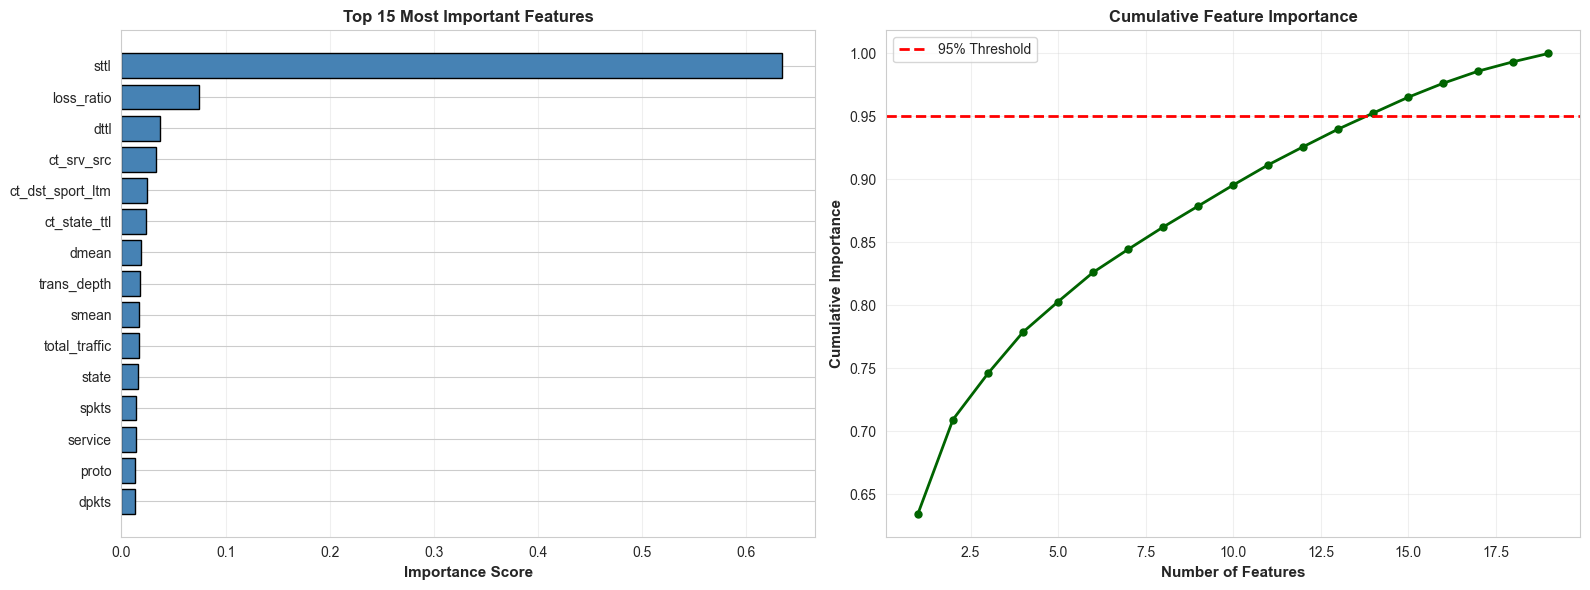

In [73]:
# Visualize feature importance with two perspectives
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features
top_15 = final_feature_importance.head(15)
axes[0].barh(range(len(top_15)), top_15['importance'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['feature'])
axes[0].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Most Important Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Cumulative importance
cumsum = final_feature_importance['importance'].cumsum() / final_feature_importance['importance'].sum()
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, marker='o', linewidth=2, markersize=5, color='darkgreen')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
axes[1].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
axes[1].set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [74]:
# Interpretation of Top Features
print("\nTOP 5 FEATURES INTERPRETATION")
print("="*80)
top_5_features = final_feature_importance.head(5)['feature'].tolist()

feature_meanings = {
    'ct_srv_src': 'Count of connections from same source to same service',
    'ct_dst_ltm': 'Count of connections to same destination in time window',
    'ct_src_dport_ltm': 'Count of connections from source to destination port',
    'sload': 'Source load (source bytes rate)',
    'dload': 'Destination load (destination bytes rate)',
    'total_traffic': 'Total traffic (sbytes + dbytes)',
    'spkts': 'Packets sent from source to destination',
    'dpkts': 'Packets sent from destination to source',
    'dur': 'Connection duration',
    'packet_rate': 'Packets per second',
    'ct_state_ttl': 'Count based on state and TTL',
}

for i, feature in enumerate(top_5_features, 1):
    importance = final_feature_importance[final_feature_importance['feature'] == feature]['importance'].values[0]
    meaning = feature_meanings.get(feature, 'Feature represents network traffic characteristic')
    print(f"\n{i}. {feature} (Importance: {importance:.6f})")
    print(f"   → {meaning}")


TOP 5 FEATURES INTERPRETATION

1. sttl (Importance: 0.634485)
   → Feature represents network traffic characteristic

2. loss_ratio (Importance: 0.074795)
   → Feature represents network traffic characteristic

3. dttl (Importance: 0.036657)
   → Feature represents network traffic characteristic

4. ct_srv_src (Importance: 0.032781)
   → Count of connections from same source to same service

5. ct_dst_sport_ltm (Importance: 0.024178)
   → Feature represents network traffic characteristic


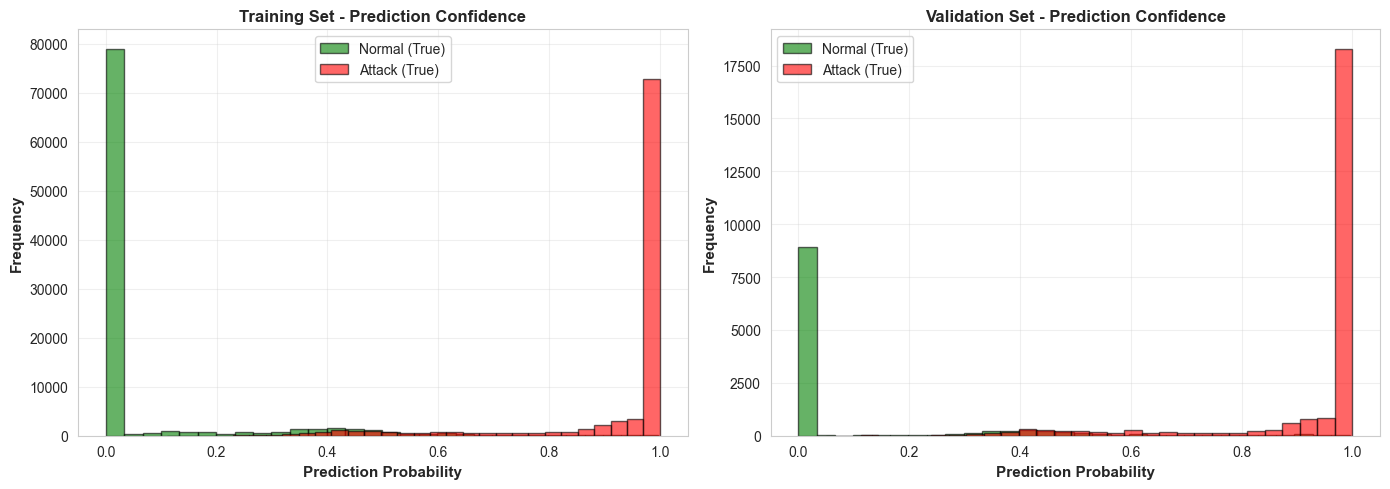

Prediction confidence analysis complete


In [75]:
# Prediction Confidence Analysis
y_pred_proba_train = model.predict_proba(X_train_final)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set prediction confidence
axes[0].hist(y_pred_proba_train[y_train_smote == 0], bins=30, alpha=0.6, label='Normal (True)', color='green', edgecolor='black')
axes[0].hist(y_pred_proba_train[y_train_smote == 1], bins=30, alpha=0.6, label='Attack (True)', color='red', edgecolor='black')
axes[0].set_xlabel('Prediction Probability', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Training Set - Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation set prediction confidence
axes[1].hist(y_pred_proba_val[y_val == 0], bins=30, alpha=0.6, label='Normal (True)', color='green', edgecolor='black')
axes[1].hist(y_pred_proba_val[y_val == 1], bins=30, alpha=0.6, label='Attack (True)', color='red', edgecolor='black')
axes[1].set_xlabel('Prediction Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Validation Set - Prediction Confidence', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Prediction confidence analysis complete")